# **Data Insertion**

In [13]:
import pandas as pd

ds = pd.read_csv("Walmart_Sales.csv")
ds

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


# Data Preparation


In [14]:

ds.columns = ds.columns.str.strip().str.lower().str.replace(' ', '_')
ds

y = ds['weekly_sales']
y

,weekly_sales
0,1643690.90
1,1641957.44
2,1611968.17
3,1409727.59
4,1554806.68
...,...
6430,713173.95
6431,733455.07
6432,734464.36
6433,718125.53


In [15]:
x = ds.drop('weekly_sales', axis=1)
x['date'] = pd.to_datetime(x['date'].str.strip(), format='%d-%m-%Y')
x

,store,date,holiday_flag,temperature,fuel_price,cpi,unemployment
0,1,2010-02-05,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...
6430,45,2012-09-28,0,64.88,3.997,192.013558,8.684
6431,45,2012-10-05,0,64.89,3.985,192.170412,8.667
6432,45,2012-10-12,0,54.47,4.000,192.327265,8.667
6433,45,2012-10-19,0,56.47,3.969,192.330854,8.667


# Data Splitting

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 42)

In [17]:
x_train['date'] = x_train['date'].apply(lambda x: x.toordinal())
x_test['date'] = x_test['date'].apply(lambda x: x.toordinal())

In [18]:
y_train

,weekly_sales
1033,836707.85
915,558963.83
5903,588592.61
2083,605413.17
5943,526641.23
...,...
3772,1709365.19
5191,508213.14
5226,510787.46
5390,342667.35


In [19]:
y_test

,weekly_sales
2436,1138800.32
3361,1304850.67
233,1769296.25
3667,1077640.13
5011,428851.99
...,...
2600,1492060.89
6308,801098.43
6292,890689.51
151,2066187.72


In [20]:
x_train #has the 80% of the data

,store,date,holiday_flag,temperature,fuel_price,cpi,unemployment
1033,8,734032,0,75.32,2.582,214.878556,6.315
915,7,734207,0,20.70,3.372,192.058484,8.818
5903,42,734088,0,61.24,3.130,126.546161,9.003
2083,15,734375,0,69.19,3.906,136.213613,7.806
5943,42,734368,0,87.40,3.743,129.240581,8.257
...,...,...,...,...,...,...,...
3772,27,734186,0,39.32,3.420,137.251185,7.827
5191,37,734109,0,54.44,2.708,210.376263,8.476
5226,37,734354,0,86.71,3.684,214.297294,8.177
5390,38,734501,1,44.64,3.428,130.071032,12.890


In [21]:
x_test #has 20% of the data

,store,date,holiday_flag,temperature,fuel_price,cpi,unemployment
2436,18,733843,0,42.39,2.805,131.784000,9.202
3361,24,734312,0,68.88,3.964,135.265267,8.212
233,2,734438,0,65.87,3.372,217.325182,7.441
3667,26,734452,0,40.08,3.570,136.461806,7.598
5011,36,733850,0,59.56,2.701,209.980321,8.554
...,...,...,...,...,...,...,...
2600,19,733990,0,74.20,2.942,132.614193,8.099
6308,45,733920,0,69.27,2.899,182.046418,8.899
6292,45,733808,0,27.31,2.784,181.871190,8.992
151,2,733864,0,63.27,2.719,210.479887,8.200


# Model Building

## Using - linear regression

In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [23]:
lr.fit(x_train, y_train)

LinearRegression()

## Using model to make prediction

In [24]:
y_train_pred = lr.predict(x_train)
y_test_pred = lr.predict(x_test)

In [25]:
y_train_pred

array([1201453.95093095, 1244090.30035794,  834609.13909235, ...,
        701464.20467319,  886714.50862644, 1244546.04779612])

In [26]:
y_test_pred

array([1194024.6737418 , 1090456.07695886, 1263540.96923843, ...,
        685189.88320243, 1260582.72741315, 1288622.41212134])

In [27]:
#Comparing predicting value with original value
from sklearn.metrics import mean_squared_error, r2_score

lr_train_mse =mean_squared_error(y_train, y_train_pred)
lr_train_r2 = r2_score(y_train, y_train_pred)

lr_test_mse = mean_squared_error(y_test, y_test_pred)
lr_test_r2 = r2_score(y_test, y_test_pred)

In [28]:
print(f"Linear regression (train) Mean Squared error: {lr_train_mse}")
print(f"Linear regression r2 score (train): {lr_train_r2}")
print(f"Linear regression (test) Mean Squared error: {lr_test_mse}")
print(f"Linear regression r2 Score (test): {lr_test_r2}")

Linear regression (train) Mean Squared error: 273187491562.2907
Linear regression r2 score (train): 0.13961361749927548
Linear regression (test) Mean Squared error: 274573999190.0615
Linear regression r2 Score (test): 0.14769483554506657


In [29]:
#for better visualisation
lr_results = pd.DataFrame(['Linear regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]).transpose()
lr_results.columns = ["Method", 'Training MSE', 'Training R2', 'Testing MSE', 'Testing R2']


In [30]:
lr_results

,Method,Training MSE,Training R2,Testing MSE,Testing R2
0,Linear regression,273187491562.29071,0.139614,274573999190.061493,0.147695


In [31]:
# comparing train vs test r2

import matplotlib.pyplot as plt
import seaborn as sns



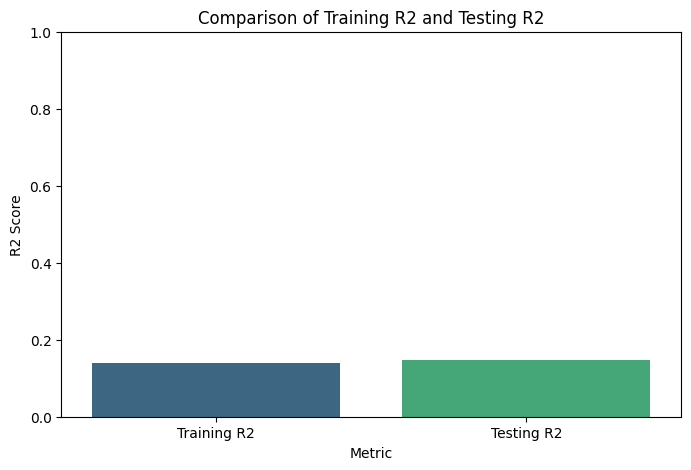

In [32]:
r2_scores = pd.DataFrame({
    'Metric': ['Training R2', 'Testing R2'],
    'Score': [lr_results['Training R2'][0], lr_results['Testing R2'][0]]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', data=r2_scores, palette='viridis', hue='Metric', legend=False)
plt.title('Comparison of Training R2 and Testing R2')
plt.ylabel('R2 Score')
plt.ylim(0, 1) # R2 scores typically range from 0 to 1
plt.show()